
# Part B — 08 Forecast Data Collection

## Goal
Build the **target dataset** for the Toronto seasonal snowfall forecasting system using official ECCC Toronto Pearson records.

Stations:
- **6158733 — Toronto Lester B. Pearson Int'l A** (historical)
- **6158731 — Toronto Intl A** (current)

This notebook downloads daily records, combines the Pearson station thread, checks completeness, and creates one row per **July–June snow season**.

**Important:** This notebook builds the snowfall target only. ENSO / El Niño and other predictors come next.


In [1]:

from pathlib import Path
from io import StringIO
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

cwd = Path.cwd()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
RAW_DIR = PROJECT_ROOT / "data" / "raw" / "eccc_pearson"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "figures"
for p in [RAW_DIR, PROCESSED_DIR, FIGURES_DIR]:
    p.mkdir(parents=True, exist_ok=True)
print("Project root:", PROJECT_ROOT)


Project root: /Users/toor/Desktop/Weather-Prediction/toronto-climate-analysis



## 1. Station configuration

ECCC's historical-data download interface uses an internal **Station ID**, different from the Climate ID.

| Station | Climate ID | Station ID | Role |
|---|---:|---:|---|
| Toronto Lester B. Pearson Int'l A | 6158733 | 5097 | historical |
| Toronto Intl A | 6158731 | 51459 | current |

The ECCC Toronto Pearson composite switches from the predecessor station to the current station in June 2013.


In [2]:

STATIONS = {
    "legacy": {"climate_id": "6158733", "station_id": 5097, "start_year": 1937, "end_year": 2013},
    "current": {"climate_id": "6158731", "station_id": 51459, "start_year": 2013, "end_year": 2026},
}
LEGACY_END = pd.Timestamp("2013-06-13")
CURRENT_START = pd.Timestamp("2013-06-14")
STATIONS


{'legacy': {'climate_id': '6158733',
  'station_id': 5097,
  'start_year': 1937,
  'end_year': 2013},
 'current': {'climate_id': '6158731',
  'station_id': 51459,
  'start_year': 2013,
  'end_year': 2026}}

## 2. Download official ECCC daily data

In [3]:

BASE_URL = "https://climate.weather.gc.ca/climate_data/bulk_data_e.html"

def download_daily_year(station_id, year, cache_dir=RAW_DIR, pause=0.15):
    cache_path = cache_dir / f"station_{station_id}_daily_{year}.csv"
    if cache_path.exists():
        return pd.read_csv(cache_path)

    params = {
        "format": "csv",
        "stationID": station_id,
        "Year": year,
        "Month": 1,
        "Day": 1,
        "timeframe": 2,
        "submit": "Download Data",
    }
    r = requests.get(BASE_URL, params=params, timeout=60)
    r.raise_for_status()
    if not r.text.strip():
        raise ValueError(f"Empty response for station {station_id}, year {year}")
    df = pd.read_csv(StringIO(r.text))
    if df.empty:
        raise ValueError(f"No rows for station {station_id}, year {year}")
    df.to_csv(cache_path, index=False)
    time.sleep(pause)
    return df

def download_station(station_id, start_year, end_year):
    frames=[]
    for year in range(start_year, end_year+1):
        try:
            d=download_daily_year(station_id, year)
            d["download_station_id"] = station_id
            d["download_year"] = year
            frames.append(d)
            print(f"Downloaded/cached station {station_id}: {year}")
        except Exception as e:
            print(f"FAILED station {station_id}, year {year}: {e}")
    if not frames:
        raise RuntimeError(f"No data downloaded for station {station_id}")
    return pd.concat(frames, ignore_index=True)


In [4]:

legacy_raw = download_station(5097, 1937, 2013)
current_raw = download_station(51459, 2013, 2026)
print("Legacy shape:", legacy_raw.shape)
print("Current shape:", current_raw.shape)


Downloaded/cached station 5097: 1937
Downloaded/cached station 5097: 1938
Downloaded/cached station 5097: 1939
Downloaded/cached station 5097: 1940
Downloaded/cached station 5097: 1941
Downloaded/cached station 5097: 1942
Downloaded/cached station 5097: 1943
Downloaded/cached station 5097: 1944
Downloaded/cached station 5097: 1945
Downloaded/cached station 5097: 1946
Downloaded/cached station 5097: 1947
Downloaded/cached station 5097: 1948
Downloaded/cached station 5097: 1949
Downloaded/cached station 5097: 1950
Downloaded/cached station 5097: 1951
Downloaded/cached station 5097: 1952
Downloaded/cached station 5097: 1953
Downloaded/cached station 5097: 1954
Downloaded/cached station 5097: 1955
Downloaded/cached station 5097: 1956
Downloaded/cached station 5097: 1957
Downloaded/cached station 5097: 1958
Downloaded/cached station 5097: 1959
Downloaded/cached station 5097: 1960
Downloaded/cached station 5097: 1961
Downloaded/cached station 5097: 1962
Downloaded/cached station 5097: 1963
D

## 3. Inspect the returned schema

In [5]:

print("Legacy columns:", legacy_raw.columns.tolist())
print("Current columns:", current_raw.columns.tolist())
display(legacy_raw.head())
display(current_raw.head())


Legacy columns: ['Longitude (x)', 'Latitude (y)', 'Station Name', 'Climate ID', 'Date/Time', 'Year', 'Month', 'Day', 'Data Quality', 'Max Temp (°C)', 'Max Temp Flag', 'Min Temp (°C)', 'Min Temp Flag', 'Mean Temp (°C)', 'Mean Temp Flag', 'Heat Deg Days (°C)', 'Heat Deg Days Flag', 'Cool Deg Days (°C)', 'Cool Deg Days Flag', 'Total Rain (mm)', 'Total Rain Flag', 'Total Snow (cm)', 'Total Snow Flag', 'Total Precip (mm)', 'Total Precip Flag', 'Snow on Grnd (cm)', 'Snow on Grnd Flag', 'Dir of Max Gust (10s deg)', 'Dir of Max Gust Flag', 'Spd of Max Gust (km/h)', 'Spd of Max Gust Flag', 'download_station_id', 'download_year']
Current columns: ['Longitude (x)', 'Latitude (y)', 'Station Name', 'Climate ID', 'Date/Time', 'Year', 'Month', 'Day', 'Data Quality', 'Max Temp (°C)', 'Max Temp Flag', 'Min Temp (°C)', 'Min Temp Flag', 'Mean Temp (°C)', 'Mean Temp Flag', 'Heat Deg Days (°C)', 'Heat Deg Days Flag', 'Cool Deg Days (°C)', 'Cool Deg Days Flag', 'Total Rain (mm)', 'Total Rain Flag', 'Total S

,Longitude (x),Latitude (y),Station Name,Climate ID,Date/Time,Year,Month,Day,Data Quality,Max Temp (°C),Max Temp Flag,Min Temp (°C),Min Temp Flag,Mean Temp (°C),Mean Temp Flag,Heat Deg Days (°C),Heat Deg Days Flag,Cool Deg Days (°C),Cool Deg Days Flag,Total Rain (mm),Total Rain Flag,Total Snow (cm),Total Snow Flag,Total Precip (mm),Total Precip Flag,Snow on Grnd (cm),Snow on Grnd Flag,Dir of Max Gust (10s deg),Dir of Max Gust Flag,Spd of Max Gust (km/h),Spd of Max Gust Flag,download_station_id,download_year
0,-79.63,43.68,TORONTO LESTER B. PEARSON INT'L A,6158733,1937-01-01,1937,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5097,1937
1,-79.63,43.68,TORONTO LESTER B. PEARSON INT'L A,6158733,1937-01-02,1937,1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5097,1937
2,-79.63,43.68,TORONTO LESTER B. PEARSON INT'L A,6158733,1937-01-03,1937,1,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5097,1937
3,-79.63,43.68,TORONTO LESTER B. PEARSON INT'L A,6158733,1937-01-04,1937,1,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5097,1937
4,-79.63,43.68,TORONTO LESTER B. PEARSON INT'L A,6158733,1937-01-05,1937,1,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5097,1937


,Longitude (x),Latitude (y),Station Name,Climate ID,Date/Time,Year,Month,Day,Data Quality,Max Temp (°C),Max Temp Flag,Min Temp (°C),Min Temp Flag,Mean Temp (°C),Mean Temp Flag,Heat Deg Days (°C),Heat Deg Days Flag,Cool Deg Days (°C),Cool Deg Days Flag,Total Rain (mm),Total Rain Flag,Total Snow (cm),Total Snow Flag,Total Precip (mm),Total Precip Flag,Snow on Grnd (cm),Snow on Grnd Flag,Dir of Max Gust (10s deg),Dir of Max Gust Flag,Spd of Max Gust (km/h),Spd of Max Gust Flag,download_station_id,download_year
0,-79.63,43.68,TORONTO INTL A,6158731,2013-01-01,2013,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,51459,2013
1,-79.63,43.68,TORONTO INTL A,6158731,2013-01-02,2013,1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,51459,2013
2,-79.63,43.68,TORONTO INTL A,6158731,2013-01-03,2013,1,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,51459,2013
3,-79.63,43.68,TORONTO INTL A,6158731,2013-01-04,2013,1,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,51459,2013
4,-79.63,43.68,TORONTO INTL A,6158731,2013-01-05,2013,1,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,51459,2013


In [6]:

def find_column(columns, candidates):
    normalized = {str(c).strip().lower(): c for c in columns}
    for candidate in candidates:
        if candidate.strip().lower() in normalized:
            return normalized[candidate.strip().lower()]
    for c in columns:
        low=str(c).strip().lower()
        for candidate in candidates:
            if candidate.strip().lower() in low:
                return c
    raise KeyError(f"Could not find {candidates}; available={list(columns)}")

def standardize_daily(df, source_label):
    date_col=find_column(df.columns,["Date/Time","Date/Time (LST)","Date"])
    snow_col=find_column(df.columns,["Total Snow (cm)","Total Snow"])
    out=pd.DataFrame()
    out["date"]=pd.to_datetime(df[date_col], errors="coerce")
    out["snowfall_raw"]=df[snow_col]
    s=df[snow_col].astype(str).str.strip()
    out["trace_snow"]=s.str.upper().eq("T")
    out["snowfall_cm"]=pd.to_numeric(s.replace({"T":"0","t":"0"}), errors="coerce")
    out["source"]=source_label
    try:
        out["station_name"]=df[find_column(df.columns,["Station Name"])].astype(str)
    except KeyError:
        out["station_name"]=np.nan
    try:
        out["climate_id"]=df[find_column(df.columns,["Climate ID"])].astype(str)
    except KeyError:
        out["climate_id"]=np.nan
    try:
        out["snow_flag"]=df[find_column(df.columns,["Total Snow Flag","Total Snow (cm) Flag"])]
    except KeyError:
        out["snow_flag"]=np.nan
    return out.dropna(subset=["date"]).copy()


In [7]:

legacy=standardize_daily(legacy_raw,"6158733_legacy")
current=standardize_daily(current_raw,"6158731_current")
print("Legacy:",legacy.date.min(),"→",legacy.date.max())
print("Current:",current.date.min(),"→",current.date.max())


Legacy: 1937-01-01 00:00:00 → 2013-12-31 00:00:00
Current: 2013-01-01 00:00:00 → 2026-12-31 00:00:00


## 4. Create the Toronto Pearson composite snowfall series

In [8]:

legacy_thread=legacy[legacy.date <= LEGACY_END].copy()
current_thread=current[current.date >= CURRENT_START].copy()
pearson_daily=(pd.concat([legacy_thread,current_thread],ignore_index=True)
               .sort_values("date").reset_index(drop=True))
print("Combined range:",pearson_daily.date.min(),"→",pearson_daily.date.max())
print("Rows:",len(pearson_daily))
print("Duplicate dates:",pearson_daily.date.duplicated().sum())
print("Missing snowfall:",pearson_daily.snowfall_cm.isna().sum())
print("Trace snowfall rows:",pearson_daily.trace_snow.sum())


Combined range: 1937-01-01 00:00:00 → 2026-12-31 00:00:00
Rows: 32872
Duplicate dates: 0
Missing snowfall: 608
Trace snowfall rows: 0


In [9]:

duplicates=pearson_daily[pearson_daily.date.duplicated(keep=False)].sort_values("date")
if len(duplicates):
    display(duplicates.head(20))
else:
    print("No duplicate dates in composite series.")


No duplicate dates in composite series.


## 5. Check daily continuity and missing snowfall

In [10]:

full_calendar=pd.DataFrame({"date":pd.date_range(pearson_daily.date.min(),pearson_daily.date.max(),freq="D")})
daily=full_calendar.merge(pearson_daily,on="date",how="left")
daily["year"]=daily.date.dt.year
daily["month"]=daily.date.dt.month
print("Expected calendar rows:",len(full_calendar))
print("Rows with missing snowfall:",daily.snowfall_cm.isna().sum())
display(daily.loc[daily.snowfall_cm.isna(),["date","source","snow_flag"]].head(20))


Expected calendar rows: 32872
Rows with missing snowfall: 608


,date,source,snow_flag
0,1937-01-01,6158733_legacy,NaN
1,1937-01-02,6158733_legacy,NaN
2,1937-01-03,6158733_legacy,NaN
3,1937-01-04,6158733_legacy,NaN
4,1937-01-05,6158733_legacy,NaN
5,1937-01-06,6158733_legacy,NaN
6,1937-01-07,6158733_legacy,NaN
7,1937-01-08,6158733_legacy,NaN
8,1937-01-09,6158733_legacy,NaN
9,1937-01-10,6158733_legacy,NaN



## 6. Build July–June snow seasons

A season is labelled by its ending year. Example: July 2025–June 2026 = `season_year = 2026`.

Missing snowfall observations are **not** treated as zero. We start with a 90% daily-observation coverage threshold and inspect the result.


In [11]:

daily["season_year"]=np.where(daily.month>=7,daily.year+1,daily.year)

def expected_season_days(y):
    start=pd.Timestamp(int(y)-1,7,1)
    end=pd.Timestamp(int(y),6,30)
    return (end-start).days+1

seasonal=(daily.groupby("season_year")
          .agg(snowfall_cm=("snowfall_cm",lambda s:s.sum(min_count=1)),
               valid_days=("snowfall_cm","count"),
               missing_days=("snowfall_cm",lambda s:s.isna().sum()),
               measurable_snow_days=("snowfall_cm",lambda s:(s>0).sum()))
          .reset_index())
seasonal["expected_days"]=seasonal.season_year.apply(expected_season_days)
seasonal["coverage_pct"]=seasonal.valid_days/seasonal.expected_days*100
seasonal["usable_90pct"]=seasonal.coverage_pct>=90

# Only seasons fully contained within the downloaded calendar.
seasonal["full_calendar_window"]=(
    (pd.to_datetime((seasonal.season_year-1).astype(str)+"-07-01") >= daily.date.min()) &
    (pd.to_datetime(seasonal.season_year.astype(str)+"-06-30") <= daily.date.max())
)
seasonal["usable"]=seasonal.usable_90pct & seasonal.full_calendar_window

display(seasonal.head(15))
display(seasonal.tail(15))


,season_year,snowfall_cm,valid_days,missing_days,measurable_snow_days,expected_days,coverage_pct,usable_90pct,full_calendar_window,usable
0,1937,NaN,0,181,0,365,0.000000,False,False,False
1,1938,91.7,242,123,20,365,66.301370,False,True,False
2,1939,207.4,365,0,65,365,100.000000,True,True,True
3,1940,89.5,244,122,31,366,66.666667,False,True,False
4,1941,164.0,365,0,40,365,100.000000,True,True,True
5,1942,96.9,365,0,42,365,100.000000,True,True,True
6,1943,182.4,365,0,50,365,100.000000,True,True,True
7,1944,123.7,366,0,41,366,100.000000,True,True,True
8,1945,162.3,365,0,58,365,100.000000,True,True,True
9,1946,89.5,365,0,39,365,100.000000,True,True,True


,season_year,snowfall_cm,valid_days,missing_days,measurable_snow_days,expected_days,coverage_pct,usable_90pct,full_calendar_window,usable
76,2013,106.7,365,0,43,365,100.000000,True,True,True
77,2014,138.4,358,7,53,365,98.082192,True,True,True
78,2015,99.3,364,1,42,365,99.726027,True,True,True
79,2016,65.9,364,2,32,366,99.453552,True,True,True
80,2017,85.2,364,1,34,365,99.726027,True,True,True
81,2018,109.7,364,1,44,365,99.726027,True,True,True
82,2019,138.5,364,1,51,365,99.726027,True,True,True
83,2020,142.4,366,0,49,366,100.000000,True,True,True
84,2021,122.0,356,9,47,365,97.534247,True,True,True
85,2022,172.0,363,2,52,365,99.452055,True,True,True


## 7. Diagnose season completeness

In [12]:

print("Total seasons:",len(seasonal))
print("Usable seasons:",seasonal.usable.sum())
usable=seasonal[seasonal.usable].copy()
if len(usable):
    print("Usable range:",f"{int(usable.season_year.min()-1)}–{int(usable.season_year.min())}","to",f"{int(usable.season_year.max()-1)}–{int(usable.season_year.max())}")
print("\nWorst coverage seasons:")
display(seasonal.sort_values("coverage_pct")[["season_year","snowfall_cm","valid_days","missing_days","expected_days","coverage_pct","usable"]].head(20))


Total seasons: 91
Usable seasons: 87
Usable range: 1938–1939 to 2025–2026

Worst coverage seasons:


,season_year,snowfall_cm,valid_days,missing_days,expected_days,coverage_pct,usable
0,1937,NaN,0,181,365,0.000000,False
90,2027,0.0,91,93,365,24.931507,False
1,1938,91.7,242,123,365,66.301370,False
3,1940,89.5,244,122,366,66.666667,False
57,1994,115.8,329,36,365,90.136986,True
56,1993,91.2,341,24,365,93.424658,True
84,2021,122.0,356,9,365,97.534247,True
77,2014,138.4,358,7,365,98.082192,True
86,2023,137.1,363,2,365,99.452055,True
85,2022,172.0,363,2,365,99.452055,True


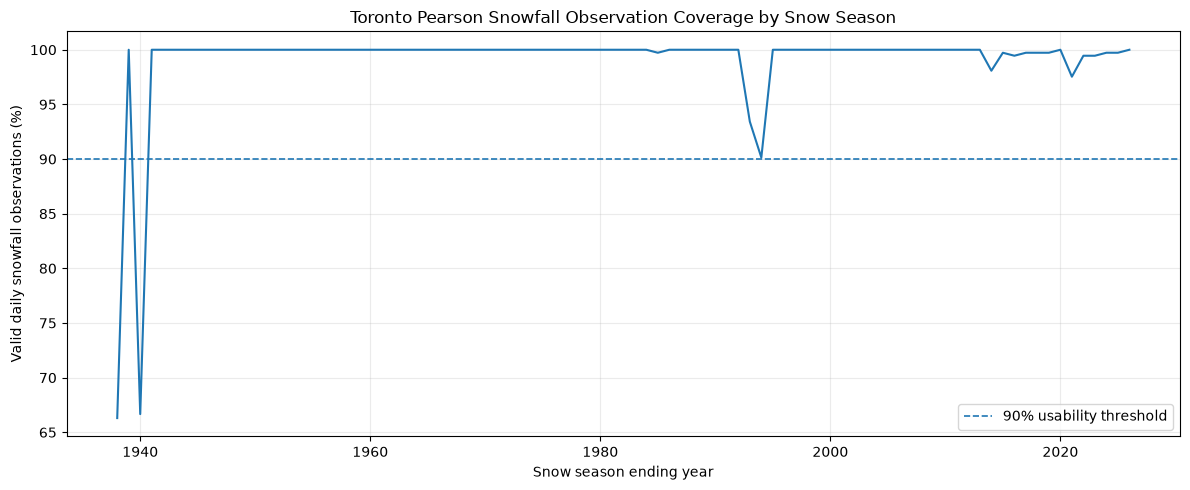

In [13]:

plot_data=seasonal[seasonal.full_calendar_window].copy()
fig,ax=plt.subplots(figsize=(12,5))
ax.plot(plot_data.season_year,plot_data.coverage_pct,linewidth=1.5)
ax.axhline(90,linestyle="--",linewidth=1.2,label="90% usability threshold")
ax.set_title("Toronto Pearson Snowfall Observation Coverage by Snow Season")
ax.set_xlabel("Snow season ending year")
ax.set_ylabel("Valid daily snowfall observations (%)")
ax.grid(alpha=.25)
ax.legend()
fig.tight_layout(); plt.show()


## 8. Inspect the target series

In [14]:

target=seasonal[seasonal.usable].copy()
display(target[["season_year","snowfall_cm","coverage_pct","measurable_snow_days"]].head(10))
print("Target summary:")
display(target.snowfall_cm.describe())


,season_year,snowfall_cm,coverage_pct,measurable_snow_days
2,1939,207.4,100.0,65
4,1941,164.0,100.0,40
5,1942,96.9,100.0,42
6,1943,182.4,100.0,50
7,1944,123.7,100.0,41
8,1945,162.3,100.0,58
9,1946,89.5,100.0,39
10,1947,146.8,100.0,54
11,1948,121.9,100.0,42
12,1949,126.5,100.0,37


Target summary:


count     87.000000
mean     122.935632
std       37.275623
min       42.800000
25%       91.500000
50%      123.700000
75%      146.150000
max      207.400000
Name: snowfall_cm, dtype: float64

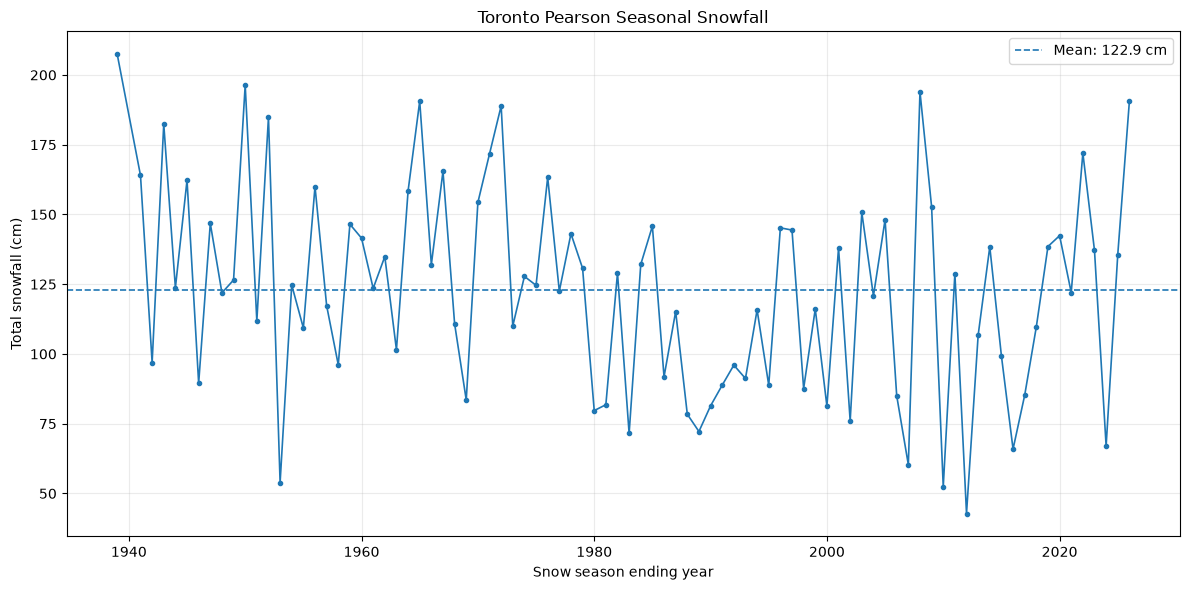

In [15]:

fig,ax=plt.subplots(figsize=(12,6))
ax.plot(target.season_year,target.snowfall_cm,marker="o",markersize=3,linewidth=1.2)
ax.axhline(target.snowfall_cm.mean(),linestyle="--",linewidth=1.2,label=f"Mean: {target.snowfall_cm.mean():.1f} cm")
ax.set_title("Toronto Pearson Seasonal Snowfall")
ax.set_xlabel("Snow season ending year")
ax.set_ylabel("Total snowfall (cm)")
ax.grid(alpha=.25); ax.legend(); fig.tight_layout()
fig.savefig(FIGURES_DIR/"part_b_target_seasonal_snowfall.png",dpi=300,bbox_inches="tight")
plt.show()


## 9. Snowiest and least snowy usable seasons

In [16]:

print("Snowiest seasons:")
display(target.nlargest(10,"snowfall_cm")[["season_year","snowfall_cm","coverage_pct"]])
print("Least snowy seasons:")
display(target.nsmallest(10,"snowfall_cm")[["season_year","snowfall_cm","coverage_pct"]])


Snowiest seasons:


,season_year,snowfall_cm,coverage_pct
2,1939,207.4,100.000000
13,1950,196.4,100.000000
71,2008,194.0,100.000000
89,2026,190.6,100.000000
28,1965,190.6,100.000000
35,1972,188.9,100.000000
15,1952,184.8,100.000000
6,1943,182.4,100.000000
85,2022,172.0,99.452055
34,1971,171.7,100.000000


Least snowy seasons:


,season_year,snowfall_cm,coverage_pct
75,2012,42.8,100.000000
73,2010,52.4,100.000000
16,1953,53.9,100.000000
70,2007,60.3,100.000000
79,2016,65.9,99.453552
87,2024,67.0,99.726776
46,1983,71.5,100.000000
52,1989,72.2,100.000000
65,2002,76.0,100.000000
51,1988,78.4,100.000000


## 10. Save Part B target data

In [17]:

daily_out=PROCESSED_DIR/"pearson_daily_snowfall.csv"
seasonal_out=PROCESSED_DIR/"pearson_seasonal_snowfall.csv"
daily.to_csv(daily_out,index=False)
seasonal.to_csv(seasonal_out,index=False)
print("Saved:",daily_out)
print("Saved:",seasonal_out)


Saved: /Users/toor/Desktop/Weather-Prediction/toronto-climate-analysis/data/processed/pearson_daily_snowfall.csv
Saved: /Users/toor/Desktop/Weather-Prediction/toronto-climate-analysis/data/processed/pearson_seasonal_snowfall.csv



# Stop here before modeling

Before adding ENSO or training any model, verify:
1. How many usable seasons do we have?
2. Are recent seasons complete?
3. Is there a suspicious discontinuity around the 2013 station transition?
4. Are there blocks of missing snowfall data?
5. Do seasonal totals look physically plausible?

Next notebook: **`09_forecast_feature_engineering.ipynb`** — ENSO/ONI, autumn temperature/precipitation, lagged snowfall, rolling climatology, and other pre-season predictors.


In [18]:
# Snow-producing portion of each season
winter_daily = daily[
    daily["month"].isin([10, 11, 12, 1, 2, 3, 4])
].copy()

winter_quality = (
    winter_daily.groupby("season_year")
    .agg(
        winter_valid_days=("snowfall_cm", "count"),
        winter_missing_days=("snowfall_cm", lambda x: x.isna().sum())
    )
    .reset_index()
)

def expected_oct_apr_days(season_year):
    start = pd.Timestamp(int(season_year) - 1, 10, 1)
    end = pd.Timestamp(int(season_year), 4, 30)
    return (end - start).days + 1

winter_quality["winter_expected_days"] = (
    winter_quality["season_year"]
    .apply(expected_oct_apr_days)
)

winter_quality["winter_coverage_pct"] = (
    winter_quality["winter_valid_days"]
    / winter_quality["winter_expected_days"]
    * 100
)

display(
    winter_quality
    .sort_values("winter_coverage_pct")
    .head(20)
)

,season_year,winter_valid_days,winter_missing_days,winter_expected_days,winter_coverage_pct
0,1937,0,120,212,0.000000
90,2027,0,92,212,0.000000
3,1940,121,92,213,56.807512
1,1938,181,31,212,85.377358
57,1994,188,24,212,88.679245
56,1993,192,20,212,90.566038
84,2021,203,9,212,95.754717
77,2014,209,3,212,98.584906
86,2023,210,2,212,99.056604
85,2022,210,2,212,99.056604


In [19]:
missing_winter = daily[
    daily["snowfall_cm"].isna()
    & daily["month"].isin([10, 11, 12, 1, 2, 3, 4])
]

display(
    missing_winter[
        ["date", "season_year", "source"]
    ].sort_values("date")
)

,date,season_year,source
0,1937-01-01,1937,6158733_legacy
1,1937-01-02,1937,6158733_legacy
2,1937-01-03,1937,6158733_legacy
3,1937-01-04,1937,6158733_legacy
4,1937-01-05,1937,6158733_legacy
...,...,...,...
32867,2026-12-27,2027,6158731_current
32868,2026-12-28,2027,6158731_current
32869,2026-12-29,2027,6158731_current
32870,2026-12-30,2027,6158731_current
